# 09b · Longitudinal GLASSO — does pain's network neighborhood shift post-DBS?

Fit the partial-correlation network at four time windows:
- **Pre-anchor** (months −24 to 0)
- **Early post** (months 6 to 18)
- **Late post** (months 24 to 48)

Track pain's partial correlation with SCOPA, NP1SLPN, REM, GDS across windows, and SCOPA/GDS centrality. Compare DBS vs Never-DBS subsets.

In [1]:
source("helpers/pain_helpers.R")
suppressPackageStartupMessages({ library(dplyr); library(tidyr); library(ggplot2); library(glasso); library(igraph); library(purrr) })
df <- readRDS(file.path(OUT_OBJ, "pain_long.rds"))

node_vars <- c("NP1PAIN","NP1SLPN","NP1SLPD","NP1FATG","NP1URIN",
               "NP1DPRS","NP1ANXS","gds","stai","ess","rem",
               "scopa","updrs3_score","BMI","LEDD")

windows <- list(
  pre        = c(-24, 0),
  early_post = c(  6, 18),
  late_post  = c( 24, 48)
)
fit_window <- function(d, win, arm = NULL) {
  dd <- d %>% dplyr::filter(months >= win[1], months <= win[2])
  if (!is.null(arm)) dd <- dd %>% dplyr::filter(will_receive_dbs == arm)
  M <- dd %>% dplyr::select(dplyr::all_of(node_vars)) %>% tidyr::drop_na() %>% as.matrix()
  if (nrow(M) < 30) return(NULL)
  S <- stats::cor(M)
  g <- glasso::glasso(S, rho = 0.12)
  Theta <- g$wi; colnames(Theta) <- rownames(Theta) <- colnames(M)
  P <- -Theta / sqrt(outer(diag(Theta), diag(Theta))); diag(P) <- 0
  list(P = P, n = nrow(M))
}

# One-row-per-visit deduplicated to one per PATNO per time_bin
df_d <- dedup_earliest_per_bin(df)
cat("Dedup rows:", nrow(df_d), "  patients:", dplyr::n_distinct(df_d$PATNO), "\n")

Warning message:
“package ‘igraph’ was built under R version 4.5.2”


Dedup rows: 647   patients: 170 


In [2]:
grid <- tidyr::expand_grid(window = names(windows),
                           arm = c("All", "DBS", "Never-DBS"))
fits <- purrr::pmap(grid, function(window, arm) {
  w <- windows[[window]]
  a <- switch(arm, All = NULL, DBS = TRUE, `Never-DBS` = FALSE)
  fit_window(df_d, w, a)
})
grid$n <- sapply(fits, function(f) if (is.null(f)) NA_integer_ else f$n)
print(grid)

# A tibble: 9 × 3
  window     arm           n
  <chr>      <chr>     <int>
1 pre        All         206
2 pre        DBS          78
3 pre        Never-DBS   128
4 early_post All          73
5 early_post DBS          46
6 early_post Never-DBS    NA
7 late_post  All          66
8 late_post  DBS          43
9 late_post  Never-DBS    NA


In [3]:
focal <- c("scopa","NP1SLPN","rem","NP1FATG","gds")
# Pain partial correlation with each focal node across windows/arms
rows <- purrr::map_dfr(seq_len(nrow(grid)), function(i) {
  f <- fits[[i]]
  if (is.null(f)) return(NULL)
  tibble::tibble(
    window = grid$window[i],
    arm    = grid$arm[i],
    n      = f$n,
    partner = focal,
    pain_pcor = f$P["NP1PAIN", focal]
  )
})
print(rows)
save_table(rows, "longitudinal_pain_pcor")

# A tibble: 35 × 5
   window arm       n partner pain_pcor
   <chr>  <chr> <int> <chr>       <dbl>
 1 pre    All     206 scopa      0.0982
 2 pre    All     206 NP1SLPN    0.0796
 3 pre    All     206 rem        0     
 4 pre    All     206 NP1FATG    0.0995
 5 pre    All     206 gds        0     
 6 pre    DBS      78 scopa      0.104 
 7 pre    DBS      78 NP1SLPN    0.0398
 8 pre    DBS      78 rem        0     
 9 pre    DBS      78 NP1FATG    0.0970
10 pre    DBS      78 gds        0     
# ℹ 25 more rows


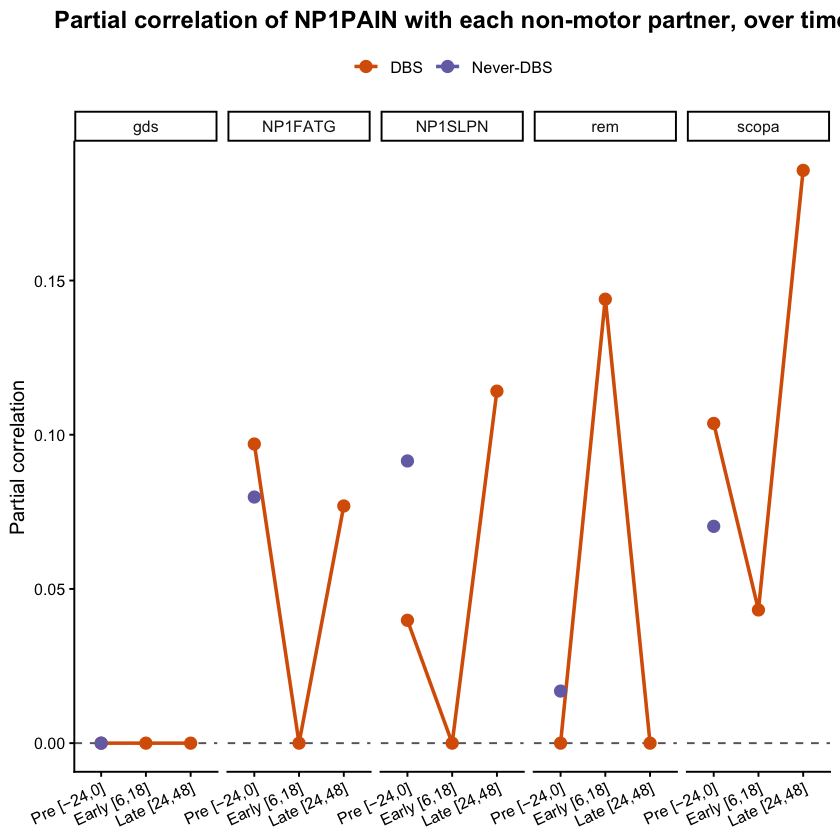

In [4]:
rows$window <- factor(rows$window, levels = c("pre","early_post","late_post"),
                     labels = c("Pre [−24,0]", "Early [6,18]", "Late [24,48]"))
p_long <- ggplot(rows %>% dplyr::filter(arm != "All"),
                 aes(x = window, y = pain_pcor, colour = arm, group = arm)) +
  geom_hline(yintercept = 0, linetype = "dashed", colour = "grey40") +
  geom_line(linewidth = 1) +
  geom_point(size = 3) +
  facet_wrap(~ partner, nrow = 1) +
  scale_colour_manual(values = c(`DBS` = "#d95f02", `Never-DBS` = "#7570b3"), name = NULL) +
  labs(title = "Partial correlation of NP1PAIN with each non-motor partner, over time",
       y = "Partial correlation", x = NULL) +
  theme_classic(base_size = 12) +
  theme(plot.title = element_text(face = "bold", hjust = 0.5),
        axis.text.x = element_text(angle = 25, hjust = 1), legend.position = "top")
p_long
save_fig(p_long, "Fig22_longitudinal_glasso", width = 11, height = 3.8)

In [5]:
# Also: SCOPA centrality (strength) over time, by arm
cent_rows <- purrr::map_dfr(seq_len(nrow(grid)), function(i) {
  f <- fits[[i]]; if (is.null(f)) return(NULL)
  A <- abs(f$P); A[A < 0.05] <- 0
  g <- igraph::graph_from_adjacency_matrix(A, mode = "undirected", weighted = TRUE, diag = FALSE)
  tibble::tibble(
    window = grid$window[i], arm = grid$arm[i], n = f$n,
    node = colnames(f$P),
    strength = igraph::strength(g)
  )
})
save_table(cent_rows, "longitudinal_centrality")
print(cent_rows %>% dplyr::filter(node %in% c("NP1PAIN","scopa","gds")) %>% dplyr::arrange(window, arm, node))

Warning message:
“The `adjmatrix` argument of `graph_from_adjacency_matrix()` must be symmetric
with mode = "undirected" as of igraph 1.6.0.
ℹ Use mode = "max" to achieve the original behavior.”


# A tibble: 21 × 5
   window     arm       n node    strength
   <chr>      <chr> <int> <chr>      <dbl>
 1 early_post All      73 NP1PAIN    0.774
 2 early_post All      73 gds        0.879
 3 early_post All      73 scopa      0.721
 4 early_post DBS      46 NP1PAIN    0.755
 5 early_post DBS      46 gds        0.857
 6 early_post DBS      46 scopa      0.736
 7 late_post  All      66 NP1PAIN    0.671
 8 late_post  All      66 gds        0.945
 9 late_post  All      66 scopa      0.574
10 late_post  DBS      43 NP1PAIN    0.708
# ℹ 11 more rows


In [6]:
save_object(fits, "longitudinal_glasso_fits")
save_object(grid, "longitudinal_glasso_grid")
cat("Saved.\n")

Saved.
